# Duration Reproduction Experiment - Refined Analysis

This notebook contains focused analyses of the duration reproduction experiment:
1. Central tendency effects (reproduction vs following comparison)
2. Following task onset and offset latency (relation to duration)
3. Sequential effects (RR, FR, RF, FF conditions)
4. N-back sanity check

Analysis follows clean, incremental principles with publication-ready visualizations.

## Setup

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_rel, ttest_1samp, pearsonr
import pingouin as pg
import statsmodels.formula.api as smf
import warnings
from pathlib import Path

# Import custom utilities
from figure_utils import *
from apa_utils import *
from analysis_utils import (
    add_response_and_bias,
    add_task_transitions,
    add_nback_durations,
    calculate_participant_metric,
    calculate_nback_correlations,
    regress_on
)

warnings.filterwarnings('ignore')

# Set plotting style
setup_publication_style()

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries loaded successfully")
print(f"✓ Pingouin version: {pg.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

✓ Libraries loaded successfully
✓ Pingouin version: 0.5.5
✓ Pandas version: 2.2.3


## Load Data

In [9]:
# Load clean aggregated data
data_path = '../data/dataAll.csv'
df = pd.read_csv(data_path)

# Display data structure
print(f"Data shape: {df.shape}")
print(f"\nParticipants: {df['nPar'].nunique()}")
print(f"Total trials: {len(df)}")
print(f"\nTask distribution:")
print(df['curTask'].value_counts())
print(f"\nFirst few rows:")
df.head()

Data shape: (13440, 17)

Participants: 24
Total trials: 13440

Task distribution:
curTask
reproduction    6720
following       6720
Name: count, dtype: int64

First few rows:


,nPar,nB,nT,curTask,curDur,rpr,flw,curPreCueDur,curRpt,preTask,preDur,preRpt,prePreCueDur,flwOnLtc,flwOffLtc,flwAfterOff,valid
0,17,1,1,reproduction,1.0,0.811564,0.000000,NaN,0.811564,NaN,NaN,NaN,NaN,NaN,NaN,False,1
1,17,1,2,following,1.3,0.000000,1.434809,0.8,1.434809,reproduction,1.0,0.811564,NaN,0.088987,0.21832,False,1
2,17,1,3,reproduction,0.8,0.799772,0.000000,NaN,0.799772,following,1.3,1.434809,0.8,NaN,NaN,False,1
3,17,1,4,reproduction,1.0,0.846837,0.000000,NaN,0.846837,reproduction,0.8,0.799772,NaN,NaN,NaN,False,1
4,17,1,5,reproduction,1.3,0.893883,0.000000,NaN,0.893883,reproduction,1.0,0.846837,NaN,NaN,NaN,False,1


## Data Preprocessing

In [10]:
# ============================================================================
# DATA PIPELINE: Consolidated Feature Engineering
# ============================================================================
# All data transformations in one place using pandas method chaining

# Load and transform data using pipeline
df = (
    pd.read_csv('../data/dataAll.csv')
    .pipe(add_response_and_bias)           # Add response, bias, relError
    .pipe(add_task_transitions)            # Add transition, taskSwitch, responseType
    .pipe(add_nback_durations, n_back=3)   # Add dur_n1, dur_n2, dur_n3 (vectorized!)
)

# Create filtered datasets
df_valid = df.query('valid == 1').copy()
df_seq = df_valid.query('transition in ["RR", "RF", "FR", "FF"]').copy()
df_follow = df_valid.query('curTask == "following"').dropna(subset=['flwOnLtc', 'flwOffLtc'])
df_nback = df_valid.query('nT > 3').copy()

# Display summary
print("="*70)
print("📊 Data Pipeline Complete")
print("="*70)
print(f"Total trials: {len(df):,}")
print(f"Valid trials: {len(df_valid):,} ({len(df_valid)/len(df)*100:.1f}%)")
print(f"Sequential trials: {len(df_seq):,}")
print(f"Following trials: {len(df_follow):,}")
print(f"N-back trials: {len(df_nback):,}")
print(f"Participants: {df['nPar'].nunique()}")

print(f"\n📋 Transition Distribution:")
print(df_seq['transition'].value_counts().sort_index())

print(f"\n🔄 Task Switch Distribution:")
print(df_seq['taskSwitch'].value_counts().sort_index())

📊 Data Pipeline Complete
Total trials: 13,440
Valid trials: 13,399 (99.7%)
Sequential trials: 13,160
Following trials: 6,701
N-back trials: 12,681
Participants: 24

📋 Transition Distribution:
transition
FF    3260
FR    3326
RF    3332
RR    3242
Name: count, dtype: int64

🔄 Task Switch Distribution:
taskSwitch
repeat    6502
switch    6658
Name: count, dtype: int64


---
# Analysis 1: Central Tendency Effects

Central tendency effect: Responses are biased toward the mean of the stimulus distribution.
- **Method**: Regress bias on current duration
- **Index**: CTI = 1 - slope (higher CTI = stronger central tendency)

## 1.1 Calculate Central Tendency Index by Participant

In [11]:
# Calculate CTI per participant and task using pandas chaining
cti_results = calculate_participant_metric(
    df_valid,
    group_cols=['nPar', 'curTask'],
    y='bias',
    x='curDur',
    metric='full'  # Get all regression stats
).assign(
    cti=lambda x: - x['slope']  # CTI =  - slope
)

# Separate by task for convenience
cti_repro = cti_results.query('curTask == "reproduction"').copy()
cti_follow = cti_results.query('curTask == "following"').copy()

# Display summary using pandas chaining
print("Central Tendency Index (CTI) Summary")
print("=" * 50)

summary = (
    cti_results
    .groupby('curTask')
    [['slope', 'cti', 'r_squared']]
    .agg(['mean', 'std'])
    .round(3)
)

print("\nReproduction Task:")
print(f"  Mean CTI: {cti_repro['cti'].mean():.3f} ± {cti_repro['cti'].std():.3f}")
print(f"  Mean slope: {cti_repro['slope'].mean():.3f} ± {cti_repro['slope'].std():.3f}")
print(f"  Mean R²: {cti_repro['r_squared'].mean():.3f}")

print(f"\nFollowing Task:")
print(f"  Mean CTI: {cti_follow['cti'].mean():.3f} ± {cti_follow['cti'].std():.3f}")
print(f"  Mean slope: {cti_follow['slope'].mean():.3f} ± {cti_follow['slope'].std():.3f}")
print(f"  Mean R²: {cti_follow['r_squared'].mean():.3f}")

Central Tendency Index (CTI) Summary

Reproduction Task:
  Mean CTI: 0.523 ± 0.258
  Mean slope: -0.523 ± 0.258
  Mean R²: 0.255

Following Task:
  Mean CTI: 0.307 ± 0.120
  Mean slope: -0.307 ± 0.120
  Mean R²: 0.144


## 1.2 Statistical Tests

In [12]:
# Test if CTI differs from 0 (no central tendency)
print("Statistical Tests for Central Tendency")
print("=" * 50)

# Reproduction task
t_stat_r, p_val_r = ttest_1samp(cti_repro['cti'], 0)
print(f"\nReproduction Task:")
print(f"  t({len(cti_repro)-1}) = {t_stat_r:.3f}, p = {p_val_r:.4f}")
print(f"  Cohen's d = {cti_repro['cti'].mean() / cti_repro['cti'].std():.3f}")

# Following task
t_stat_f, p_val_f = ttest_1samp(cti_follow['cti'], 0)
print(f"\nFollowing Task:")
print(f"  t({len(cti_follow)-1}) = {t_stat_f:.3f}, p = {p_val_f:.4f}")
print(f"  Cohen's d = {cti_follow['cti'].mean() / cti_follow['cti'].std():.3f}")

# Compare between tasks (paired t-test)
t_stat_comp, p_val_comp = ttest_rel(cti_repro['cti'], cti_follow['cti'])
print(f"\nReproduction vs Following (paired t-test):")
print(f"  t({len(cti_repro)-1}) = {t_stat_comp:.3f}, p = {p_val_comp:.4f}")
mean_diff = cti_repro['cti'].mean() - cti_follow['cti'].mean()
print(f"  Mean difference: {mean_diff:.3f}")

Statistical Tests for Central Tendency

Reproduction Task:
  t(23) = 9.911, p = 0.0000
  Cohen's d = 2.023

Following Task:
  t(23) = 12.573, p = 0.0000
  Cohen's d = 2.566

Reproduction vs Following (paired t-test):
  t(23) = 4.223, p = 0.0003
  Mean difference: 0.216


## 1.3 & 2.2 Combined Publication Figure: Central Tendency & Latency

Saved: ../figures/combined_cti_latency.png
Saved: ../figures/combined_cti_latency.pdf


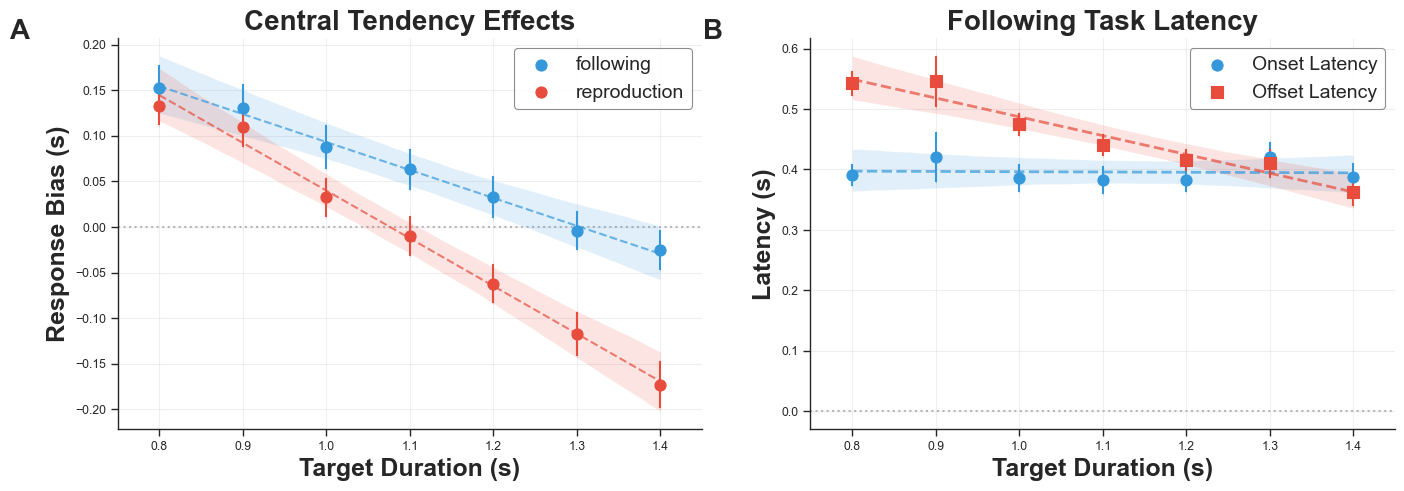


📊 Central Tendency Statistics (Panel A)
Reproduction: M = 0.52, SD = 0.26
Following: M = 0.31, SD = 0.12
Comparison: t(23) = 4.22, p < .001, d = 0.86

📊 Latency Slope Statistics (Panel B)


NameError: name 'latency_slopes_df' is not defined

In [ ]:
# ============================================================================
# COMBINED FIGURE: Central Tendency (A) + Following Latency (B)
# ============================================================================

# Prepare data for both panels
# Panel A: Central tendency
plot_data_cti = (
    df_valid
    .groupby(['nPar', 'curTask', 'curDur'], as_index=False)
    .agg(bias=('bias', 'mean'))
)

# Panel B: Following latency
plot_data_latency = (
    df_follow
    .groupby(['nPar', 'curDur'], as_index=False)
    .agg(
        onset=('flwOnLtc', 'mean'),
        offset=('flwOffLtc', 'mean')
    )
    .melt(
        id_vars=['nPar', 'curDur'],
        value_vars=['onset', 'offset'],
        var_name='latency_type',
        value_name='latency'
    )
    .assign(
        latency_type=lambda x: x['latency_type'].map({
            'onset': 'Onset',
            'offset': 'Offset'
        })
    )
)

# Create figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================================
# PANEL A: Central Tendency
# ============================================================================
plot_with_regression(
    data=plot_data_cti,
    x='curDur',
    y='bias',
    hue='curTask',
    ax=ax1,
    palette=TASK_COLORS,
    errorbar='se',
    markersize=8
)

# Formatting for Panel A
ax1.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=0)
ax1.set_xlabel('Target Duration (s)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Response Bias (s)', fontsize=18, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=14,
          edgecolor='gray', framealpha=0.9)
ax1.grid(True, alpha=0.3, linewidth=0.8)
ax1.set_xlim(0.75, 1.45)
ax1.set_title('Central Tendency Effects', fontsize=20, fontweight='bold')   
add_panel_label(ax1, 'A', x=-0.15, y=1.05, fontsize=20)
sns.despine(ax=ax1)

# ============================================================================
# PANEL B: Following Latency
# ============================================================================
colors = {'Onset': '#3498DB', 'Offset': '#E74C3C'}
markers = {'Onset': 'o', 'Offset': 's'}

for lat_type, color in colors.items():
    data = plot_data_latency.query('latency_type == @lat_type')
    
    # Aggregate for error bars
    agg_data = compute_errorbar_data(data, x='curDur', y='latency', errorbar='se')
    
    # Scatter points with error bars
    ax2.scatter(
        agg_data['curDur'], agg_data['y_mean'],
        color=color, marker=markers[lat_type], s=64, zorder=3,
        label=f'{lat_type} Latency'
    )
    
    ax2.errorbar(
        agg_data['curDur'], agg_data['y_mean'],
        yerr=agg_data['y_err'],
        fmt='none', color=color, capsize=0.1,
        linewidth=1.5, capthick=1.5, zorder=2
    )
    
    # Regression line
    sns.regplot(
        data=data, x='curDur', y='latency',
        scatter=False, color=color, ax=ax2,
        line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.7}
    )

# Formatting for Panel B
ax2.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=0)
ax2.set_xlabel('Target Duration (s)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Latency (s)', fontsize=18, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, fontsize=14,
          edgecolor='gray', framealpha=0.9)
ax2.grid(True, alpha=0.3, linewidth=0.8)
ax2.set_xlim(0.75, 1.45)
ax2.set_title('Following Task Latency', fontsize=20, fontweight='bold')
add_panel_label(ax2, 'B', x=-0.15, y=1.05, fontsize=20)
sns.despine(ax=ax2)

# Save combined figure
plt.tight_layout()
save_figure(fig, '../figures/combined_cti_latency', formats=['png', 'pdf'])
plt.show()

# ============================================================================
# STATISTICAL SUMMARIES
# ============================================================================
print("\n" + "=" * 70)
print("📊 Central Tendency Statistics (Panel A)")
print("=" * 70)

cti_repro_mean = cti_repro['cti'].mean()
cti_follow_mean = cti_follow['cti'].mean()
t_comp, p_comp = ttest_rel(cti_repro['cti'], cti_follow['cti'])
d_comp = cohens_d_paired(cti_repro['cti'].values - cti_follow['cti'].values)

print(f"Reproduction: M = {cti_repro_mean:.2f}, SD = {cti_repro['cti'].std():.2f}")
print(f"Following: M = {cti_follow_mean:.2f}, SD = {cti_follow['cti'].std():.2f}")
print(f"Comparison: {format_ttest(t_comp, 23, p_comp, d_comp)}")



---
# Analysis 2: Following Task Latency

Analyze onset and offset latencies in relation to current duration.
- **Onset latency**: Time from Gabor onset to key press
- **Offset latency**: Time from Gabor offset to key release

## 2.1 Statistical Analysis

In [ ]:
# Calculate latency statistics using pandas chaining
print("Following Task Latency Analysis")
print("=" * 50)

# Overall statistics
print(f"\nOnset Latency:")
print(f"  Mean: {df_follow['flwOnLtc'].mean():.3f} ± {df_follow['flwOnLtc'].std():.3f} s")
print(f"\nOffset Latency:")
print(f"  Mean: {df_follow['flwOffLtc'].mean():.3f} ± {df_follow['flwOffLtc'].std():.3f} s")

# Overall regression slopes
slope_on, intercept_on, r_on, p_on, se_on = stats.linregress(
    df_follow['curDur'], df_follow['flwOnLtc']
)
slope_off, intercept_off, r_off, p_off, se_off = stats.linregress(
    df_follow['curDur'], df_follow['flwOffLtc']
)

print(f"\n" + "="*50)
print("Latency vs Duration Relationship:")
print(f"\nOnset Latency ~ Duration:")
print(f"  Slope: {slope_on:.3f} ± {se_on:.3f}")
print(f"  Intercept: {intercept_on:.3f}")
print(f"  R² = {r_on**2:.3f}, p = {p_on:.4f}")

print(f"\nOffset Latency ~ Duration:")
print(f"  Slope: {slope_off:.3f} ± {se_off:.3f}")
print(f"  Intercept: {intercept_off:.3f}")
print(f"  R² = {r_off**2:.3f}, p = {p_off:.4f}")

# Per-participant slopes using pandas chaining
latency_slopes_df = (
    df_follow
    .groupby('nPar', group_keys=False)
    .filter(lambda x: len(x) >= 3)  # Remove participants with < 3 trials
    .groupby('nPar')
    .apply(lambda x: pd.Series({
        'onset_slope': stats.linregress(x['curDur'], x['flwOnLtc']).slope,
        'offset_slope': stats.linregress(x['curDur'], x['flwOffLtc']).slope
    }))
    .reset_index()
)

print(f"\n" + "="*50)
print("Per-Participant Slopes:")
print(f"\nOnset Slope: {latency_slopes_df['onset_slope'].mean():.3f} ± {latency_slopes_df['onset_slope'].std():.3f}")
print(f"Offset Slope: {latency_slopes_df['offset_slope'].mean():.3f} ± {latency_slopes_df['offset_slope'].std():.3f}")

# Test slopes against zero
t_on_slope, p_on_slope = ttest_1samp(latency_slopes_df['onset_slope'], 0)
t_off_slope, p_off_slope = ttest_1samp(latency_slopes_df['offset_slope'], 0)
print(f"\nOnset slope vs 0: t({len(latency_slopes_df)-1}) = {t_on_slope:.3f}, p = {p_on_slope:.4f}")
print(f"Offset slope vs 0: t({len(latency_slopes_df)-1}) = {t_off_slope:.3f}, p = {p_off_slope:.4f}")

# Compare onset vs offset slopes
t_slope_comp, p_slope_comp = ttest_rel(latency_slopes_df['onset_slope'], latency_slopes_df['offset_slope'])
print(f"\nOnset vs Offset slope (paired t-test): t({len(latency_slopes_df)-1}) = {t_slope_comp:.3f}, p = {p_slope_comp:.4f}")

Following Task Latency Analysis

Onset Latency:
  Mean: 0.396 ± 0.566 s

Offset Latency:
  Mean: 0.456 ± 0.515 s

Latency vs Duration Relationship:

Onset Latency ~ Duration:
  Slope: -0.002 ± 0.035
  Intercept: 0.398
  R² = 0.000, p = 0.9442

Offset Latency ~ Duration:
  Slope: -0.309 ± 0.031
  Intercept: 0.796
  R² = 0.014, p = 0.0000

Per-Participant Slopes:

Onset Slope: -0.001 ± 0.124
Offset Slope: -0.308 ± 0.146

Onset slope vs 0: t(23) = -0.034, p = 0.9730
Offset slope vs 0: t(23) = -10.323, p = 0.0000

Onset vs Offset slope (paired t-test): t(23) = 12.563, p = 0.0000


---
# Analysis 3: Sequential Effects

Analyze how previous trial duration influences current trial bias.
- **Method**: Regress bias on previous duration, separately for each transition type
- **SDI** (Serial Dependence Index) = slope of bias ~ preDur

## 3.1 Calculate Serial Dependence Index

In [7]:
# Calculate SDI per participant and transition using pandas chaining
sdi_results = (
    calculate_participant_metric(
        df_seq,
        group_cols=['nPar', 'transition'],
        y='bias',
        x='preDur',
        metric='full'  # Get all regression stats
    )
    .rename(columns={'slope': 'sdi'})  # SDI = slope of bias ~ preDur
    .assign(
        n_trials=lambda x: x.groupby(['nPar', 'transition'])['sdi'].transform('count'),
        # Add response type and task switch (already in df_seq, but add for clarity)
        responseType=lambda x: x['transition'].map({
            'RR': 'reproduction', 'FR': 'reproduction',
            'RF': 'following', 'FF': 'following'
        }),
        taskSwitch=lambda x: x['transition'].map({
            'RR': 'repeat', 'FF': 'repeat',
            'RF': 'switch', 'FR': 'switch'
        })
    )
)

# Summary by transition type using pandas chaining
print("Serial Dependence Index (SDI) by Transition Type")
print("=" * 50)

for trans in ['RR', 'FR', 'RF', 'FF']:
    trans_data = sdi_results.query('transition == @trans')
    print(f"\n{trans} (n={len(trans_data)} participants):")
    print(f"  Mean SDI: {trans_data['sdi'].mean():.3f} ± {trans_data['sdi'].std():.3f}")
    print(f"  Mean R²: {trans_data['r_squared'].mean():.3f}")
    if 'n_trials' in trans_data.columns:
        print(f"  Mean trials: {trans_data['n_trials'].mean():.0f}")

Serial Dependence Index (SDI) by Transition Type

RR (n=24 participants):
  Mean SDI: 0.092 ± 0.073
  Mean R²: 0.011
  Mean trials: 1

FR (n=24 participants):
  Mean SDI: 0.065 ± 0.100
  Mean R²: 0.011
  Mean trials: 1

RF (n=24 participants):
  Mean SDI: -0.018 ± 0.093
  Mean R²: 0.007
  Mean trials: 1

FF (n=24 participants):
  Mean SDI: 0.049 ± 0.096
  Mean R²: 0.013
  Mean trials: 1


## 3.2 Statistical Tests - Repeated Measures ANOVA

In [ ]:
print("Statistical Tests for Sequential Effects")
print("=" * 50)

# Test each transition type against zero WITH BONFERRONI CORRECTION
print("\nOne-sample t-tests (SDI vs 0):")
print("(Bonferroni-corrected α = 0.05/4 = 0.0125)")

bonferroni_alpha = 0.05 / 4  # 4 tests

for trans in ['RR', 'FR', 'RF', 'FF']:
    trans_data = sdi_results[sdi_results['transition'] == trans]['sdi'].dropna()
    t_stat, p_val = ttest_1samp(trans_data, 0)
    p_corr = min(p_val * 4, 1.0)  # Bonferroni correction
    cohens_d = trans_data.mean() / trans_data.std()
    sig_marker = "***" if p_corr < 0.001 else "**" if p_corr < 0.01 else "*" if p_corr < 0.05 else "n.s."
    print(f"\n{trans}:")
    print(f"  t({len(trans_data)-1}) = {t_stat:.3f}, p = {p_val:.4f}, p_corr = {p_corr:.4f} {sig_marker}, d = {cohens_d:.3f}")

# Prepare data for repeated measures ANOVA
# Need wide format with all transitions for each participant
sdi_wide = sdi_results.pivot(index='nPar', columns='transition', values='sdi')
sdi_wide = sdi_wide[['RR', 'FR', 'RF', 'FF']].dropna()  # Keep only participants with all 4 conditions

print(f"\n" + "="*50)
print(f"Repeated Measures ANOVA (n={len(sdi_wide)} participants with all conditions)")
print("="*50)

# Convert to long format for pingouin
sdi_long = sdi_wide.reset_index().melt(
    id_vars='nPar', 
    value_vars=['RR', 'FR', 'RF', 'FF'],
    var_name='transition',
    value_name='sdi'
)

# Run repeated measures ANOVA
aov = pg.rm_anova(data=sdi_long, dv='sdi', within='transition', subject='nPar', detailed=True)
print("\nANOVA Results:")
print(aov.to_string())

# Post-hoc pairwise comparisons with Bonferroni correction
print("\n" + "="*50)
print("Post-hoc Pairwise Comparisons (Bonferroni corrected):")
print("="*50)

posthoc = pg.pairwise_tests(
    data=sdi_long, 
    dv='sdi', 
    within='transition', 
    subject='nPar',
    padjust='bonf',
    effsize='hedges'
)
print(posthoc[['A', 'B', 'T', 'p-unc', 'p-corr', 'hedges']].to_string())

Statistical Tests for Sequential Effects

One-sample t-tests (SDI vs 0):
(Bonferroni-corrected α = 0.05/4 = 0.0125)

RR:
  t(23) = 6.184, p = 0.0000, p_corr = 0.0000 ***, d = 1.262

FR:
  t(23) = 3.205, p = 0.0039, p_corr = 0.0157 *, d = 0.654

RF:
  t(23) = -0.938, p = 0.3580, p_corr = 1.0000 n.s., d = -0.191

FF:
  t(23) = 2.502, p = 0.0199, p_corr = 0.0797 n.s., d = 0.511

Repeated Measures ANOVA (n=24 participants with all conditions)

ANOVA Results:
       Source        SS  DF        MS         F     p-unc       ng2       eps
0  transition  0.158257   3  0.052752  6.744544  0.000468  0.171749  0.810449
1       Error  0.539683  69  0.007821       NaN       NaN       NaN       NaN

Post-hoc Pairwise Comparisons (Bonferroni corrected):
    A   B         T     p-unc    p-corr    hedges
0  FF  FR -0.725864  0.475244  1.000000 -0.165049
1  FF  RF  2.229679  0.035819  0.214912  0.694139
2  FF  RR -2.063746  0.050502  0.303015 -0.501222
3  FR  RF  2.814706  0.009832  0.058991  0.846025
4 

## 3.2b Statistical Tests - Response Type × Task Switch ANOVA

Test whether sequential effects (SDI) differ by:
- **Response type**: Reproduction vs Following (current task)
- **Task switch**: Repeat (RR, FF) vs Switch (RF, FR)

In [ ]:
# Add response type and task switch columns to SDI results
sdi_results_2way = sdi_results.copy()
sdi_results_2way['responseType'] = sdi_results_2way['transition'].map({
    'RR': 'reproduction',
    'FR': 'reproduction',
    'RF': 'following',
    'FF': 'following'
})
sdi_results_2way['taskSwitch'] = sdi_results_2way['transition'].map({
    'RR': 'repeat',
    'FF': 'repeat',
    'RF': 'switch',
    'FR': 'switch'
})

print("Response Type × Task Switch ANOVA on Sequential Effects")
print("=" * 70)

# Pivot to wide format for repeated measures ANOVA
# We need to create combinations of response type and task switch
sdi_2way = sdi_results_2way.pivot_table(
    index='nPar',
    columns=['responseType', 'taskSwitch'],
    values='sdi'
).reset_index()

# Flatten column names
sdi_2way.columns = ['nPar'] + [f'{resp}_{switch}' for resp, switch in sdi_2way.columns[1:]]

# Check if we have all 4 conditions
required_cols = ['reproduction_repeat', 'reproduction_switch', 'following_repeat', 'following_switch']
sdi_2way_complete = sdi_2way[['nPar'] + required_cols].dropna()

print(f"\nParticipants with all conditions: {len(sdi_2way_complete)}")

# Convert to long format for pingouin
sdi_2way_long = sdi_2way_complete.melt(
    id_vars='nPar',
    value_vars=required_cols,
    var_name='condition',
    value_name='sdi'
)

# Split condition into responseType and taskSwitch
sdi_2way_long[['responseType', 'taskSwitch']] = sdi_2way_long['condition'].str.split('_', expand=True)
sdi_2way_long = sdi_2way_long.drop('condition', axis=1)

# Run 2-way repeated measures ANOVA
print("\n" + "=" * 70)
print("2-Way Repeated Measures ANOVA")
print("=" * 70)

aov_2way = pg.rm_anova(
    data=sdi_2way_long,
    dv='sdi',
    within=['responseType', 'taskSwitch'],
    subject='nPar',
    detailed=True
)

print("\nANOVA Results:")
print(aov_2way.to_string())

# Calculate means for each condition
print("\n" + "=" * 70)
print("Descriptive Statistics")
print("=" * 70)

means_2way = sdi_2way_long.groupby(['responseType', 'taskSwitch']).agg({
    'sdi': ['mean', 'std', 'count']
}).reset_index()
means_2way.columns = ['responseType', 'taskSwitch', 'mean', 'std', 'count']

print("\n" + means_2way.to_string(index=False))

# Post-hoc comparisons for significant effects
if aov_2way.loc[aov_2way['Source'] == 'responseType', 'p-unc'].values[0] < 0.05:
    print("\n" + "=" * 70)
    print("Main Effect of Response Type: Post-hoc Tests")
    print("=" * 70)
    
    repro_sdi = sdi_2way_long[sdi_2way_long['responseType'] == 'reproduction']['sdi']
    follow_sdi = sdi_2way_long[sdi_2way_long['responseType'] == 'following']['sdi']
    
    # Aggregate by participant first (for paired t-test)
    repro_mean = sdi_2way_long[sdi_2way_long['responseType'] == 'reproduction'].groupby('nPar')['sdi'].mean()
    follow_mean = sdi_2way_long[sdi_2way_long['responseType'] == 'following'].groupby('nPar')['sdi'].mean()
    
    t_stat, p_val = ttest_rel(repro_mean, follow_mean)
    print(f"\nReproduction (M={repro_mean.mean():.3f}, SD={repro_mean.std():.3f}) vs")
    print(f"Following (M={follow_mean.mean():.3f}, SD={follow_mean.std():.3f})")
    print(f"t({len(repro_mean)-1}) = {t_stat:.3f}, p = {p_val:.4f}")

if aov_2way.loc[aov_2way['Source'] == 'taskSwitch', 'p-unc'].values[0] < 0.05:
    print("\n" + "=" * 70)
    print("Main Effect of Task Switch: Post-hoc Tests")
    print("=" * 70)
    
    # Aggregate by participant first (for paired t-test)
    repeat_mean = sdi_2way_long[sdi_2way_long['taskSwitch'] == 'repeat'].groupby('nPar')['sdi'].mean()
    switch_mean = sdi_2way_long[sdi_2way_long['taskSwitch'] == 'switch'].groupby('nPar')['sdi'].mean()
    
    t_stat, p_val = ttest_rel(repeat_mean, switch_mean)
    print(f"\nRepeat (M={repeat_mean.mean():.3f}, SD={repeat_mean.std():.3f}) vs")
    print(f"Switch (M={switch_mean.mean():.3f}, SD={switch_mean.std():.3f})")
    print(f"t({len(repeat_mean)-1}) = {t_stat:.3f}, p = {p_val:.4f}")

if aov_2way.loc[aov_2way['Source'] == 'responseType * taskSwitch', 'p-unc'].values[0] < 0.05:
    print("\n" + "=" * 70)
    print("Interaction: Response Type × Task Switch")
    print("=" * 70)
    print("\nPairwise comparisons:")
    
    posthoc_2way = pg.pairwise_tests(
        data=sdi_2way_long,
        dv='sdi',
        within=['responseType', 'taskSwitch'],
        subject='nPar',
        padjust='bonf',
        effsize='hedges'
    )
    print(posthoc_2way[['A', 'B', 'Contrast', 'T', 'p-unc', 'p-corr', 'hedges']].to_string())

Response Type × Task Switch ANOVA on Sequential Effects

Participants with all conditions: 24

2-Way Repeated Measures ANOVA

ANOVA Results:
                      Source        SS  ddof1  ddof2        MS          F     p-unc  p-GG-corr       ng2  eps
0               responseType  0.096053      1     23  0.096053  22.763259  0.000082   0.000082  0.111789  1.0
1                 taskSwitch  0.052709      1     23  0.052709   6.853380  0.015380   0.015380  0.064603  1.0
2  responseType * taskSwitch  0.009494      1     23  0.009494   0.821746  0.374070   0.374070  0.012287  1.0

Descriptive Statistics

responseType taskSwitch      mean      std  count
   following     repeat  0.048851 0.095669     24
   following     switch -0.017903 0.093500     24
reproduction     repeat  0.092224 0.073056     24
reproduction     switch  0.065250 0.099750     24

Main Effect of Response Type: Post-hoc Tests

Reproduction (M=0.079, SD=0.058) vs
Following (M=0.015, SD=0.060)
t(23) = 4.771, p = 0.0001

Main

## 3.3 Publication Figure: Sequential Effects (2×2 Panels)


In [ ]:
# Sequential effects visualization - FIXED: use plot_points_with_errors instead of pointplot
# Prepare tidy data for faceted plotting
plot_data = (
    df_seq
    .groupby(['curTask', 'taskSwitch', 'preDur', 'nPar'])
    .agg(bias=('bias', 'mean'))
    .reset_index()
)

# Color and style mappings
switch_colors = {'repeat': '#E74C3C', 'switch': '#3498DB'}
switch_markers = {'repeat': 'o', 'switch': 's'}
switch_labels = {'repeat': 'Task Repeat', 'switch': 'Task Switch'}

# Create FacetGrid
g = sns.FacetGrid(
    data=plot_data,
    col='curTask',
    hue='taskSwitch',
    palette=switch_colors,
    height=5,
    aspect=1.2,
    legend_out=False,
    col_order=['reproduction', 'following']
)

# Map points with error bars using NEW function (continuous x-axis)
g.map_dataframe(
    plot_points_with_errors,
    x='preDur',
    y='bias',
    errorbar='se',
    capsize=0.1,
    markersize=7
)

# Add regression lines using utility function
add_regression_lines_to_facet(
    g, df_seq,
    x='preDur', y='bias',
    col_var='curTask', hue_var='taskSwitch',
    palette=switch_colors
)

# Formatting
g.set_axis_labels('Previous Duration (s)', 'Response Bias (s)', fontsize=18, fontweight='bold')
g.set_titles(col_template='{col_name}', size=20, weight='bold')

# Add zero lines to all facets
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=0)
    ax.grid(True, alpha=0.3, linewidth=0.8)

# Custom legend with better labels
g.add_legend(title='', labels=switch_labels, frameon=True,
            edgecolor='gray', framealpha=0.9)

despine_all(g.fig)
plt.tight_layout()
save_figure(g.fig, '../figures/sequential_effects', formats=['png', 'pdf'])
plt.show()

## 3.4 Publication Figure: SDI Comparison


In [ ]:
# Create figure with SEM error bars (consistent with other figures)
fig, ax = plt.subplots(figsize=(7, 5))

# Use barplot with explicit SEM errorbar
sns.barplot(
    data=sdi_results, 
    x="responseType", 
    y="sdi", 
    hue="taskSwitch",
    errorbar='se',  # EXPLICIT: Use SEM for consistency with Figures 1-2
    capsize=0.1,
    ax=ax
)

# Formatting
ax.set_xlabel('Response Type', fontsize=18, fontweight='bold')
ax.set_ylabel('Serial Dependence Index (SDI)', fontsize=18, fontweight='bold')
ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.legend(title='', frameon=True, edgecolor='gray', framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
sns.despine(ax=ax)

plt.tight_layout()
save_figure(fig, '../figures/sdi_comparison', formats=['png', 'pdf'])
plt.show()

print("\nNote: Error bars represent ±1 SEM (consistent with Figures 1-2)")

## 3.5 Comprehensive Linear Mixed-Effects Model

Unified model combining both central tendency and sequential effects.
- **Fixed effects**: curDur, preDur, curTask, preTask, and key interactions
- **Random effects**: participant (intercept + slopes for curDur and preDur)
- **Key advantage**: Simultaneously estimates both effects while accounting for correlations

In [ ]:
import statsmodels.formula.api as smf
from apa_utils import format_lmm_fixed_effect
from scipy.stats import chi2
import warnings

def calculate_aic_bic(result):
    """Calculate AIC and BIC manually from MixedLM result."""
    if result is None:
        return None, None
    
    llf = result.llf
    n_obs = result.nobs
    k = result.k_fe + result.k_re + result.k_vc + 1  # +1 for residual variance
    
    aic = -2 * llf + 2 * k
    bic = -2 * llf + k * np.log(n_obs)
    
    return aic, bic

print("=" * 70)
print("Comprehensive Linear Mixed-Effects Models")
print("Combining Current Duration (Central Tendency) and")
print("Previous Duration (Sequential Dependence)")
print("=" * 70)
print("Note: Using ML (not REML) for valid LRT comparison of fixed effects")

# Prepare data
df_lmm = df_seq.copy()
df_lmm['nPar'] = df_lmm['nPar'].astype(str)
df_lmm['curDur_c'] = df_lmm['curDur'] - df_lmm['curDur'].mean()
df_lmm['preDur_c'] = df_lmm['preDur'] - df_lmm['preDur'].mean()

# ============================================================================
# FIT ALL 5 MODELS (ML for valid LRT; REML for final parameter estimates)
# ============================================================================
models_spec = {
    '1: Main Effects': 'bias ~ curDur_c + preDur_c + C(curTask) + C(preTask)',
    '2: Task Interactions': 'bias ~ curDur_c + preDur_c + C(curTask)*C(preTask)',
    '3: Duration×Task': 'bias ~ curDur_c * C(curTask) + preDur_c * C(preTask) + C(curTask):C(preTask)',
    '4: Duration×Tasks + preTask': 'bias ~ curDur_c * C(curTask) + preDur_c * C(curTask) + preDur_c * C(preTask) + C(curTask):C(preTask)',
    '5: Duration×TaskSwitch': 'bias ~ curDur_c * C(curTask) + preDur_c * C(taskSwitch) + C(curTask):C(taskSwitch)'
}

results_ml = {}
results_reml = {}
models_data = []

print("\n" + "=" * 70)
print("Fitting Models (ML)...")
print("=" * 70)

for model_name, formula in models_spec.items():
    print(f"\n{model_name}: ", end='')
    
    # ML fit for model comparison
    model_ml = smf.mixedlm(
        formula, data=df_lmm, groups=df_lmm['nPar'],
        re_formula='~curDur_c + preDur_c'
    )
    # REML fit for parameter estimates
    model_reml = smf.mixedlm(
        formula, data=df_lmm, groups=df_lmm['nPar'],
        re_formula='~curDur_c + preDur_c'
    )
    
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            result_ml = model_ml.fit(method='lbfgs', maxiter=2000, reml=False)
            result_reml = model_reml.fit(method='lbfgs', maxiter=2000, reml=True)
        
        aic, bic = calculate_aic_bic(result_ml)
        results_ml[model_name] = result_ml
        results_reml[model_name] = result_reml
        
        models_data.append({
            'Model': model_name,
            'AIC': aic,
            'BIC': bic,
            'LogLik': result_ml.llf,
            'df': result_ml.k_fe + result_ml.k_re + result_ml.k_vc + 1,
            'Converged': result_ml.converged
        })
        
        print(f"✓ Converged (AIC={aic:.1f}, BIC={bic:.1f})")
        
    except Exception as e:
        results_ml[model_name] = None
        results_reml[model_name] = None
        print(f"✗ Failed: {e}")

# ============================================================================
# MODEL COMPARISON (ML-based)
# ============================================================================
print("\n" + "=" * 70)
print("Model Comparison (ML-based AIC/BIC)")
print("=" * 70)

comparison = pd.DataFrame(models_data)
print("\n" + comparison.to_string(index=False))

best_aic_idx = comparison['AIC'].idxmin()
best_bic_idx = comparison['BIC'].idxmin()

delta_aic = comparison['AIC'] - comparison['AIC'].min()
delta_bic = comparison['BIC'] - comparison['BIC'].min()

print(f"\n{'Model':<42} {'Δ AIC':>10} {'Δ BIC':>10}")
print("-" * 65)
for idx, row in comparison.iterrows():
    aic_marker = " (AIC)" if idx == best_aic_idx else ""
    bic_marker = " (BIC)" if idx == best_bic_idx else ""
    print(f"{row['Model']:<42} {delta_aic[idx]:>10.1f} {delta_bic[idx]:>10.1f}{aic_marker}{bic_marker}")

if best_aic_idx != best_bic_idx:
    print(f"\nNote: AIC favors Model {comparison.loc[best_aic_idx, 'Model'][:1]}, "
          f"BIC favors Model {comparison.loc[best_bic_idx, 'Model'][:1]}")

# ============================================================================
# LIKELIHOOD RATIO TESTS (ML-based)
# ============================================================================
print("\n" + "=" * 70)
print("Likelihood Ratio Tests (ML-based)")
print("=" * 70)

pairs = [
    ('1: Main Effects', '2: Task Interactions', 1),
    ('2: Task Interactions', '3: Duration×Task', 2),
    ('3: Duration×Task', '4: Duration×Tasks + preTask', 1),
]

for m1_name, m2_name, df_diff in pairs:
    r1 = results_ml[m1_name]
    r2 = results_ml[m2_name]
    if r1 and r2:
        lr = 2 * (r2.llf - r1.llf)
        p = 1 - chi2.cdf(lr, df_diff) if lr > 0 else 1.0
        print(f"\n{m1_name} vs {m2_name}:")
        print(f"  χ²({df_diff}) = {lr:.3f}, p = {p:.4f}")
        if p < 0.001:
            print(f"  → Significantly better (p < .001)")
        elif p < 0.05:
            print(f"  → Significantly better (p = {p:.3f})")
        else:
            print(f"  → No significant improvement")

# ============================================================================
# DETAILED OUTPUT FOR BEST MODEL (REML estimates)
# ============================================================================
# Use Model 4 (best by AIC) for detailed output
best_model_name = comparison.loc[best_aic_idx, 'Model']
best_result = results_reml[best_model_name]
best_ml = results_ml[best_model_name]

print("\n" + "=" * 70)
print(f"Best Model (AIC): {best_model_name}")
print("=" * 70)
print(f"\nFormula: {models_spec[best_model_name]}")
print(f"Random: (curDur + preDur | participant)")
print(f"\nML Log-Likelihood: {best_ml.llf:.2f}")

aic, bic = calculate_aic_bic(best_ml)
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
print(f"N observations: {best_ml.nobs}")

print("\nFixed Effects (REML estimates):")
print("-" * 70)
for param_name in best_result.params.index:
    if param_name != 'Group Var':
        print(format_lmm_fixed_effect(
            name=param_name,
            coef=best_result.params[param_name],
            se=best_result.bse[param_name],
            z=best_result.tvalues[param_name],
            p=best_result.pvalues[param_name]
        ))

# Also print Model 3 (best by BIC) for comparison
bic_model_name = comparison.loc[best_bic_idx, 'Model']
if bic_model_name != best_model_name:
    bic_result = results_reml[bic_model_name]
    bic_ml = results_ml[bic_model_name]
    print("\n" + "=" * 70)
    print(f"Best Model (BIC): {bic_model_name}")
    print("=" * 70)
    print(f"\nFormula: {models_spec[bic_model_name]}")
    print(f"\nML Log-Likelihood: {bic_ml.llf:.2f}")
    aic3, bic3 = calculate_aic_bic(bic_ml)
    print(f"AIC: {aic3:.2f}")
    print(f"BIC: {bic3:.2f}")
    
    print("\nFixed Effects (REML estimates):")
    print("-" * 70)
    for param_name in bic_result.params.index:
        if param_name != 'Group Var':
            print(format_lmm_fixed_effect(
                name=param_name,
                coef=bic_result.params[param_name],
                se=bic_result.bse[param_name],
                z=bic_result.tvalues[param_name],
                p=bic_result.pvalues[param_name]
            ))

# ============================================================================
# RANDOM EFFECTS (from best AIC model)
# ============================================================================
print("\n" + "=" * 70)
print("Random Effects (Best AIC Model, REML)")
print("=" * 70)
print("\nVariance-Covariance Matrix:")
print(best_result.cov_re)
print(f"\nResidual variance: {best_result.scale:.4f}")

if best_result.cov_re.shape[0] >= 2:
    corr_matrix = best_result.cov_re / np.sqrt(np.outer(np.diag(best_result.cov_re), np.diag(best_result.cov_re)))
    print(f"\nCorrelation Matrix:")
    print(corr_matrix)


**Model Interpretations:**

1. **Model 1 (Main Effects)**: Baseline model testing independent effects of current duration, previous duration, current task, and previous task

2. **Model 2 (Task Interactions)**: Adds interaction between current and previous task to test if task switching modulates bias

3. **Model 3 (Duration×Task)**: Tests whether central tendency (curDur effect) and sequential dependence (preDur effect) differ by task type

4. **Model 4 (Duration×Tasks + preTask)**: Full model allowing both duration effects to vary with current task, plus interaction with previous task

5. **Model 5 (Duration×Tasks + taskSwitch)**: Tests whether task switching (repeat vs switch) modulates duration effects

**Key Advantages of Unified LMM:**
- Simultaneously estimates central tendency and sequential effects while controlling for each other
- Accounts for individual differences via random slopes
- Provides accurate uncertainty estimates for repeated measures
- AIC/BIC comparison identifies optimal model complexity

---
# Analysis 4: N-Back Sanity Check

Verify that n-1 (most recent) trial has the strongest influence on current bias, validating the sequential effects analysis focusing on n-1 duration.

## 4.1 Calculate N-Back Correlations

In [ ]:
# Calculate n-back correlations using utility function (returns tidy DataFrame!)
nback_corr = calculate_nback_correlations(df_nback, max_n=3, group_col='curTask')

# Display results
print("N-Back Correlation Analysis")
print("=" * 50)

for task in ['reproduction', 'following']:
    task_data = nback_corr.query('curTask == @task')
    print(f"\n{task.capitalize()} Task:")
    for _, row in task_data.iterrows():
        print(f"  n-{row['n_back']}: r = {row['r']:.3f}, p = {row['p']:.4f} (n={row['n_obs']})")

# Statistical comparison: is n-1 stronger than n-2 and n-3?
print("\n" + "="*50)
print("Comparing N-Back Effects:")

comparison = (
    nback_corr
    .assign(abs_r=lambda x: abs(x['r']))
    .pivot(index='curTask', columns='n_back', values='abs_r')
)

for task in ['reproduction', 'following']:
    if task in comparison.index:
        r1 = comparison.loc[task, 1]
        r2 = comparison.loc[task, 2]
        r3 = comparison.loc[task, 3]
        print(f"\n{task.capitalize()}:")
        print(f"  n-1 correlation: {r1:.3f}")
        print(f"  n-2 correlation: {r2:.3f} (diff = {r1 - r2:.3f})")
        print(f"  n-3 correlation: {r3:.3f} (diff = {r1 - r3:.3f})")

N-Back Correlation Analysis

Reproduction Task:
  n-1: r = 0.064, p = 0.0000 (n=6334)
  n-2: r = 0.026, p = 0.0387 (n=6334)
  n-3: r = 0.021, p = 0.0944 (n=6334)

Following Task:
  n-1: r = 0.013, p = 0.3110 (n=6347)
  n-2: r = 0.014, p = 0.2635 (n=6347)
  n-3: r = 0.007, p = 0.6019 (n=6347)

Comparing N-Back Effects:

Reproduction:
  n-1 correlation: 0.064
  n-2 correlation: 0.026 (diff = 0.038)
  n-3 correlation: 0.021 (diff = 0.043)

Following:
  n-1 correlation: 0.013
  n-2 correlation: 0.014 (diff = -0.001)
  n-3 correlation: 0.007 (diff = 0.006)


## 4.2 Correlation Analysis

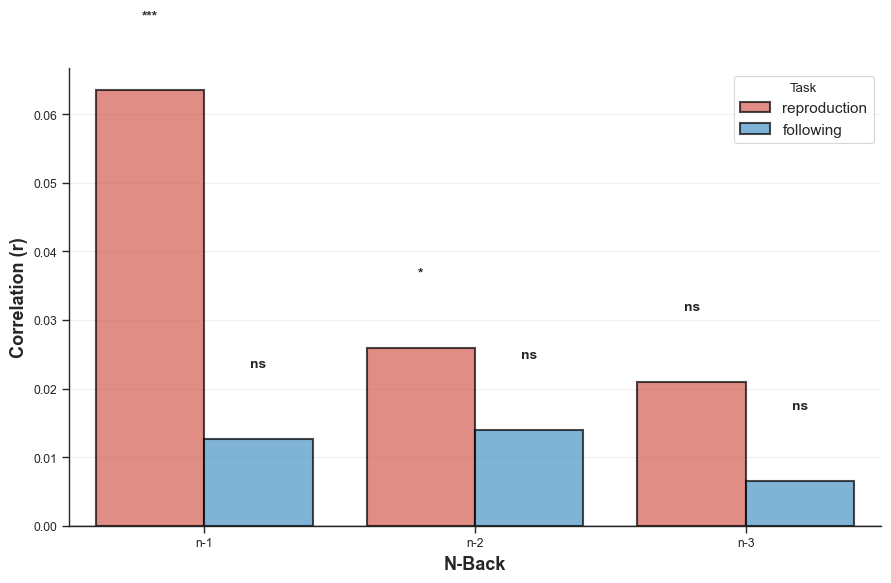

Figure saved: ../figures/nback_sanity_check.png


In [ ]:
# N-back visualization using seaborn catplot (declarative!)
# nback_corr is already in tidy format from calculate_nback_correlations()

fig = sns.catplot(
    data=nback_corr,
    x='n_back',
    y='r',
    hue='curTask',
    kind='bar',
    palette={'reproduction': '#E74C3C', 'following': '#3498DB'},
    height=6,
    aspect=1.5,
    alpha=0.7,
    edgecolor='black',
    linewidth=1.5,
    legend_out=False
)

# Add significance stars
for _, row in nback_corr.iterrows():
    stars = format_pvalue_stars(row['p'])
    # Calculate x position (seaborn uses 0-indexed positions)
    x_offset = -0.2 if row['curTask'] == 'reproduction' else 0.2
    x_pos = row['n_back'] - 1 + x_offset
    y_pos = row['r'] + (0.01 if row['r'] > 0 else -0.01)
    va = 'bottom' if row['r'] > 0 else 'top'
    
    fig.ax.text(x_pos, y_pos, stars, ha='center', va=va,
               fontsize=10, fontweight='bold')

# Formatting
fig.ax.axhline(0, color='black', linestyle='-', linewidth=1)
fig.set_axis_labels('N-Back', 'Correlation (r)', fontsize=13, fontweight='bold')
fig.ax.set_xticks([0, 1, 2])
fig.ax.set_xticklabels(['n-1', 'n-2', 'n-3'])
fig.ax.legend(loc='best', fontsize=11, title='Task')
fig.ax.grid(True, alpha=0.3, axis='y')
sns.despine(ax=fig.ax)

plt.tight_layout()
plt.savefig('../figures/nback_sanity_check.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: ../figures/nback_sanity_check.png")

## 4.3 Visualization: N-Back Effects

---
# Summary

This notebook analyzed four key aspects of the duration reproduction experiment:

1. **Central Tendency Effects**: Both tasks show regression to the mean, compared in single plot
2. **Following Task Latency**: Analyzed relationship between latency and duration (slopes)
3. **Sequential Effects**: SDI analyzed with repeated-measures ANOVA across RR, FR, RF, FF
4. **N-Back Sanity Check**: Strongest effects at n-1, validating sequential analysis

All figures saved to `../figures/`

In [ ]:
# Verify statsmodels installation
import statsmodels.api as sm
import statsmodels.formula.api as smf
print(f"statsmodels version: {sm.__version__}")

statsmodels version: 0.14.2
